# GreenSurge event reconstruction example tropical cyclone

## Read simulation dataset

In [1]:
import xarray as xr
import numpy as np

In [2]:
ds_GFD_info = xr.open_dataset(
    "inputs/GreenSurge_Cadiz_info.nc",
    decode_times=False,
)
ds_GFD_info

<xarray.Dataset> Size: 76kB
Dimensions:                            (element_computation_index: 2801,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 26,
                                        element_forcing_index: 34,
                                        wind_direction_index: 24,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 1503)
Coordinates:
  * element_computation_index          (element_computation_index) int32 11kB ...
  * node_forcing_index                 (node_forcing_index) int32 104B 0 ... 25
  * element_forcing_index              (element_forcing_index) int32 136B 0 ....
  * wind_direction_index               (wind_direction_index) int32 96B 0 ... 23
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int32 6kB 0 ....
    node_computation_longitude         (node_cumputation_index) float64 12kB ...
    node_computation_latitude          (node_cumputation_index) float64 12kB ...
    triangle_nodes                     (triangle_forcing_nodes) int32 12B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 34kB ...
    node_forcing_longitude             (node_forcing_index) float64 208B ...
    node_forcing_latitude              (node_forcing_index) float64 208B ...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int32 408B ...
    wind_directions                    (wind_direction_index) int32 96B ...
    total_elements                     int32 4B ...
    ...                                 ...
    wind_speed                         int32 4B ...
    location_name                      object 8B ...
    eddy_viscosity                     int32 4B ...
    chezy_coefficient                  int32 4B ...
    reference_date                     object 8B ...
    forcing_time_step                  int32 4B ...
Attributes:
    title:        GreenSurge Simulation Input Dataset
    institution:  GeoOcean
    model:        GreenSurge
    created:      2026-03-05 14:22:11

## Generate a regular grid for the vortex model and apply the vortex model to the storm track

In [3]:
from bluemath_tk.additive.additive import get_regular_grid
import pandas as pd
from scipy.ndimage import gaussian_filter

lon_grid, lat_grid = get_regular_grid(
    node_computation_longitude=ds_GFD_info.node_computation_longitude.values,
    node_computation_latitude=ds_GFD_info.node_computation_latitude.values,
    node_computation_elements=ds_GFD_info.triangle_computation_connectivity.values,
    factor=10,
)

# ---------------------------
# Dimensions
# ---------------------------
nlat = len(lat_grid)
nlon = len(lon_grid)
ntime = 78

time = pd.date_range("2005-10-08 06:00:00", periods=ntime, freq="1H")

# Create 2D grid
lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)

# Convert degrees to meters (approx)
R_earth = 6371000
lat0 = np.mean(lat_grid)

x = np.deg2rad(lon2d - lon2d.mean()) * R_earth * np.cos(np.deg2rad(lat0))
y = np.deg2rad(lat2d - lat2d.mean()) * R_earth

# ---------------------------
# Allocate arrays
# ---------------------------
W = np.zeros((nlat, nlon, ntime))
Dir = np.zeros((nlat, nlon, ntime))
p = np.zeros((nlat, nlon, ntime))

# ---------------------------
# Cyclone parameters
# ---------------------------
Vmax = 45        # max wind speed (m/s)
Rmax = 30000     # radius of max wind (30 km)
p_env = 101300   # environmental pressure (Pa)
dp = 5000        # central pressure drop (Pa)

for t in range(ntime):
    
    # Moving center (diagonal track)
    xc = -50000 + t * 1500
    yc = -50000 + t * 800
    
    # Distance from center
    r = np.sqrt((x - xc)**2 + (y - yc)**2)
    
    # Avoid division by zero
    r[r == 0] = 1
    
    # Radial wind profile (smooth Gaussian-like)
    V = Vmax * (r / Rmax) * np.exp(1 - r / Rmax)
    
    # Pressure profile
    p_t = p_env - dp * np.exp(-(r / Rmax)**2)
    
    # Tangential wind components (cyclonic rotation NH)
    U = -V * (y - yc) / r
    Vv =  V * (x - xc) / r
    
    # Speed and direction
    speed = np.sqrt(U**2 + Vv**2)
    direction = (270 - np.degrees(np.arctan2(Vv, U))) % 360
    
    W[:, :, t] = speed
    Dir[:, :, t] = direction
    p[:, :, t] = p_t

# ---------------------------
# Build dataset
# ---------------------------
ds_wind = xr.Dataset(
    {
        "W": (("lat", "lon", "time"), W),
        "Dir": (("lat", "lon", "time"), Dir),
        "p": (("lat", "lon", "time"), p),
    },
    coords={
        "lat": lat_grid,
        "lon": lon_grid,
        "time": time,
    },
)

ds_wind

<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 34, lon: 37, time: 78)
Coordinates:
  * lat      (lat) float64 272B 43.49 43.49 43.49 43.49 ... 43.55 43.55 43.55
  * lon      (lon) float64 296B -3.63 -3.627 -3.624 ... -3.53 -3.527 -3.524
  * time     (time) datetime64[ns] 624B 2005-10-08T06:00:00 ... 2005-10-11T11...
Data variables:
    W        (lat, lon, time) float64 785kB 30.29 31.17 32.06 ... 33.02 32.15
    Dir      (lat, lon, time) float64 785kB 134.6 134.1 133.6 ... 353.1 352.6
    p        (lat, lon, time) float64 785kB 1.013e+05 1.012e+05 ... 1.012e+05

In [4]:
dynamic_path = "outputs/Dynamic/"

In [5]:
from datetime import datetime

reference_datetime = datetime.strptime(
    str(ds_wind.time.values[0]).split('.')[0].replace('T', ' '),
    "%Y-%m-%d %H:%M:%S"
)
simulation_end_datetime = datetime.strptime(
    str(ds_wind.time.values[-1]).split('.')[0].replace('T', ' '),
    "%Y-%m-%d %H:%M:%S"
)

drag_coefficients = [0.00063, 0.00723, 0.00723]
velocity_thresholds = [0, 100, 100]
wind_equilibrium_code = 2

metamodel_parameters = {
    "vortex": [ds_wind],
}

fixed_parameters = {
    "MapInterval": 3600 * ds_GFD_info.time_step_hours.values,
    "RefDate": reference_datetime.strftime("%Y%m%d"),
    "StartDateTime": reference_datetime.strftime("%Y%m%d%H%M%S"),
    "StopDateTime": simulation_end_datetime.strftime("%Y%m%d%H%M%S"),
    "CDa": drag_coefficients[0],
    "CDb": drag_coefficients[1],
    "CDc": drag_coefficients[2],
    "VCDa": velocity_thresholds[0],
    "VCDb": velocity_thresholds[1],
    "VCDc": velocity_thresholds[2],
    "Wind_eq": wind_equilibrium_code,
    "eddy": ds_GFD_info.eddy_viscosity.values,
    "chezy": ds_GFD_info.chezy_coefficient.values,
    "W2Map": 1,
    "dt_forz": ds_GFD_info.forcing_time_step.values,
    "SetupType": "Dynamic",
    "forcing_ds": "forcing.nc",
    "mesh_path": f"templates/mesh_{ds_GFD_info.location_name.values}_net.nc",
    "NetFile": f"mesh_{ds_GFD_info.location_name.values}_net.nc",
}

from bluemath_tk.wrappers.delft3d.delft3d_wrapper import GreenSurgeModelWrapper

delft3d_wrapper = GreenSurgeModelWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=dynamic_path,
)

delft3d_wrapper.build_cases()

2026-03-05 18:30:15,989 - GreenSurgeModelWrapper - WARNING - Parameter vortex is not in the default_parameters


In [ ]:
delft3d_wrapper.run_cases(launcher="launchDelft3dcomp.sh")

ds_WL_dynamic_WindSetUp = xr.open_dataset(f"{dynamic_path}/0000/dflowfmoutput/GreenSurge_GFDcase_map.nc")

In [7]:
from bluemath_tk.additive.additive import wind_partition_triangular

xds_vortex_interp = wind_partition_triangular(
    ds_GFD_info=ds_GFD_info, xds_vortex=ds_wind
)

In [31]:
xds_vortex_interp

<xarray.Dataset> Size: 64kB
Dimensions:  (element: 34, time: 78)
Coordinates:
  * element  (element) int32 136B 0 1 2 3 4 5 6 7 8 ... 26 27 28 29 30 31 32 33
  * time     (time) datetime64[ns] 624B 2005-10-08T06:00:00 ... 2005-10-11T11...
Data variables:
    Dir      (element, time) float64 21kB 134.6 134.1 133.7 ... 349.8 349.4
    W        (element, time) float64 21kB 29.78 30.66 31.55 ... 30.49 29.61
    p        (element, time) float64 21kB 1.013e+05 1.013e+05 ... 1.013e+05

In [8]:
figsize = (10, 5)

instant = np.round(np.arange(2/3, 1, 1/12) * len(xds_vortex_interp.time)).astype(int)[:-1]

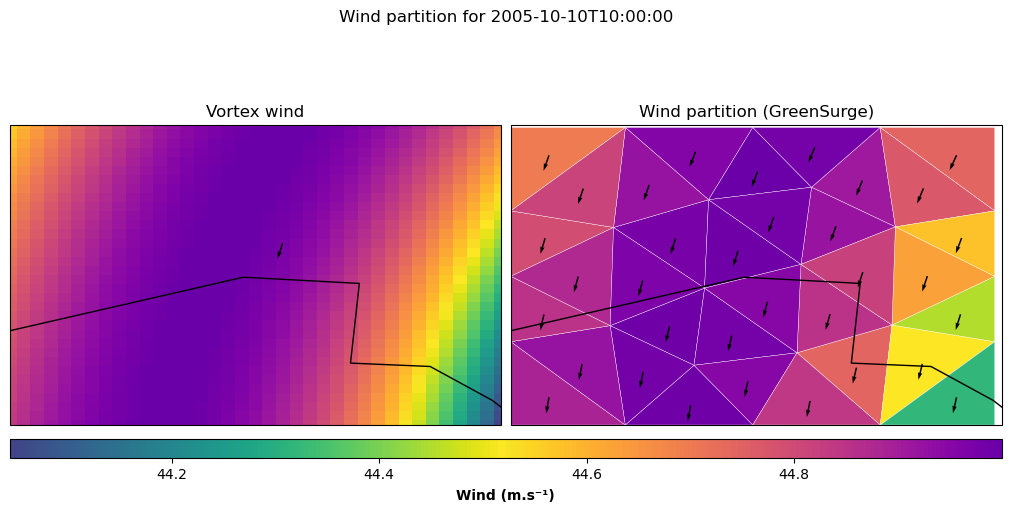

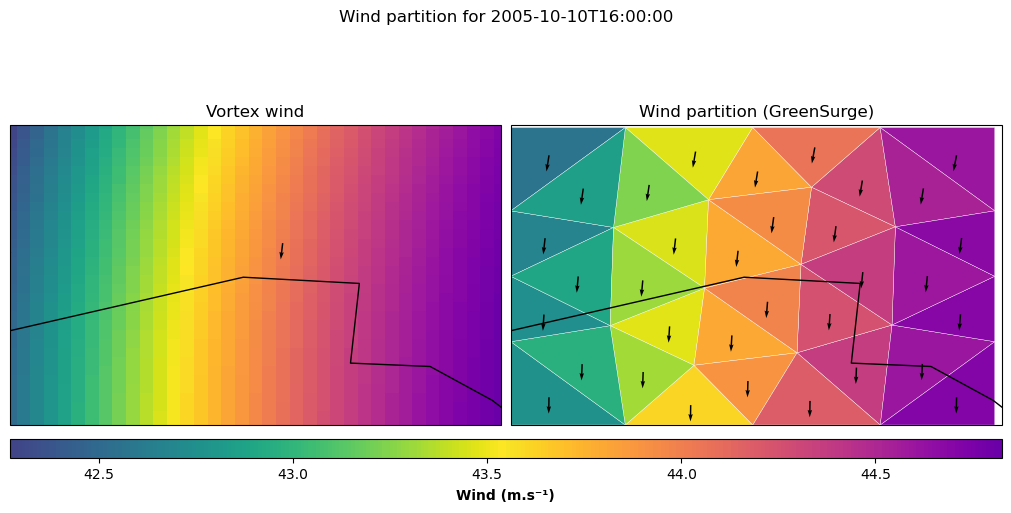

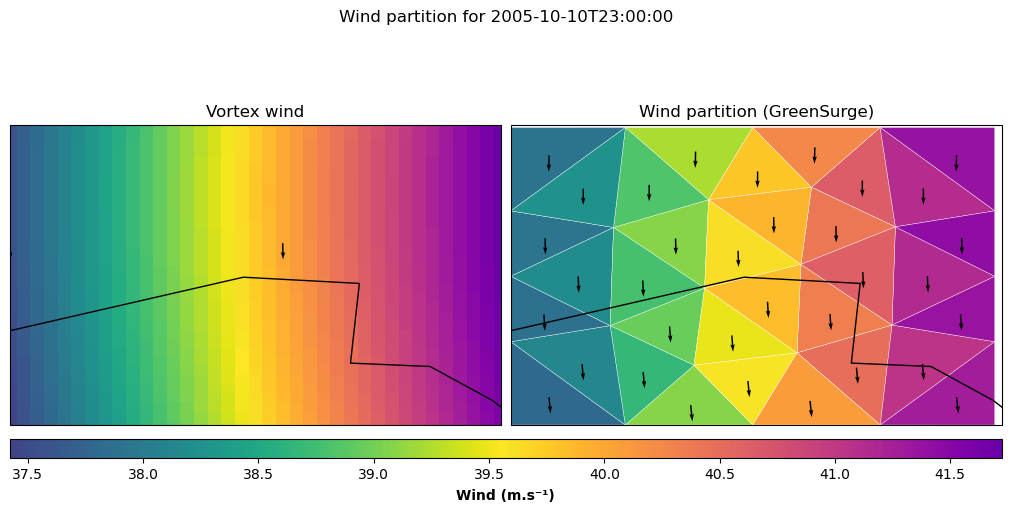

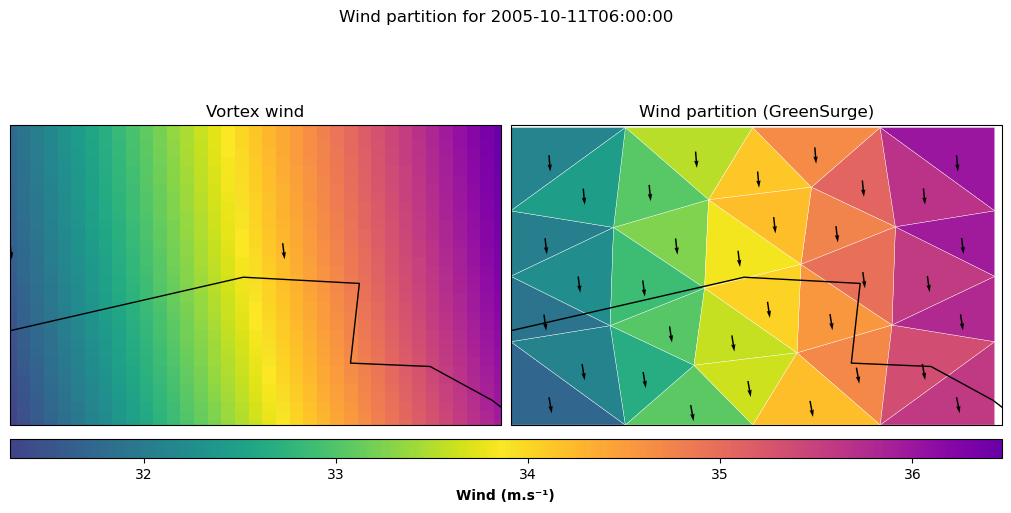

In [9]:
from bluemath_tk.additive.additive import plot_additive_input_wind_partition

for i in instant:
    plot_additive_input_wind_partition(
        xds_vortex_GS=ds_wind,
        xds_vortex_interp=xds_vortex_interp,
        ds_GFD_info=ds_GFD_info,
        i_time=i,
        figsize=figsize,
    )

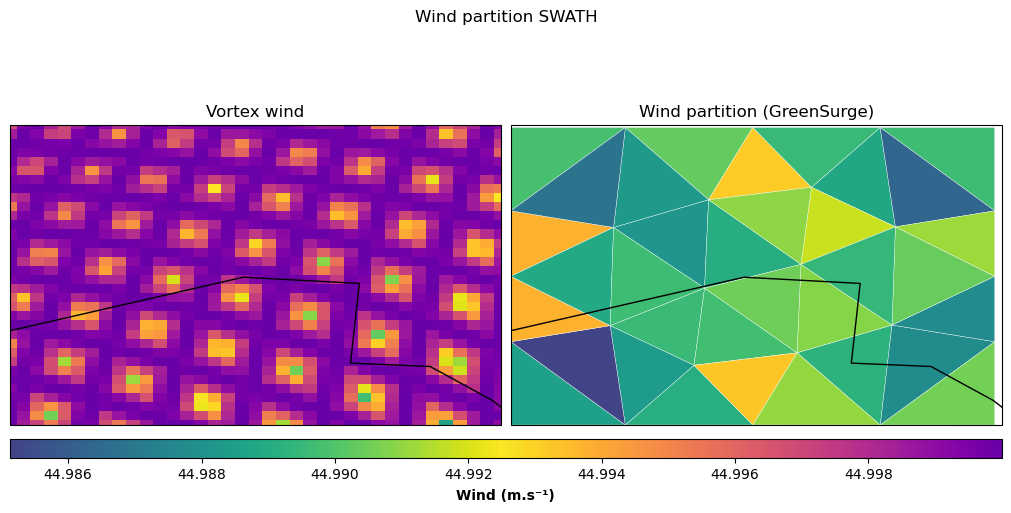

In [10]:
plot_additive_input_wind_partition(
    xds_vortex_GS=ds_wind,
    xds_vortex_interp=xds_vortex_interp,
    ds_GFD_info=ds_GFD_info,
    SWATH=True,
    figsize=figsize,
)

In [11]:
from bluemath_tk.additive.greenwaves import greenwaves_wind_setup_reconstruction_raw
greensurge_dataset="outputs/GreenSurge_Cadiz"
ds_wind_setup = greenwaves_wind_setup_reconstruction_raw(greensurge_dataset=greensurge_dataset, 
                                      ds_GFD_info_update=ds_GFD_info,
                                      xds_vortex_interp=xds_vortex_interp)

Processing time steps: 100%|██████████| 77/77 [00:00<00:00, 623.24it/s]


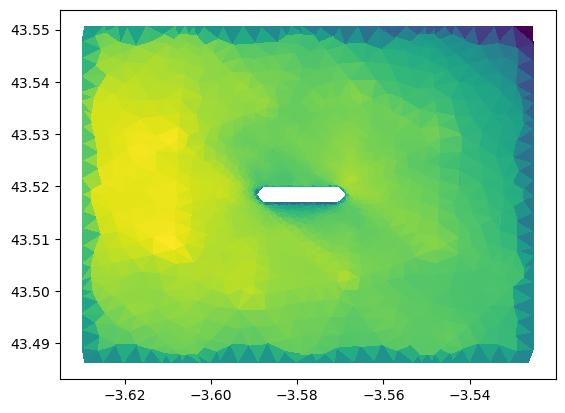

In [30]:
import matplotlib.pyplot as plt
Longitude_dynamic = ds_GFD_info.node_computation_longitude.values
Latitude_dynamic = ds_GFD_info.node_computation_latitude.values
conn = ds_GFD_info.triangle_computation_connectivity.values

plt.tripcolor(
    Longitude_dynamic,
    Latitude_dynamic,
    conn,
    facecolors=np.mean(ds_wind_setup.WL.isel(time = 10).values[conn], axis = 1),
)

In [ ]:
from bluemath_tk.additive.additive import plot_additive_vs_dynamic_windsetup_swath

plot_additive_vs_dynamic_windsetup_swath(
    ds_WL_GS_WindSetUp=ds_wind_setup,
    ds_WL_dynamic_WindSetUp=ds_wind_setup,
    ds_gfd_metadata=ds_GFD_info,
    vmin=0,
    vmax=np.nanmax(ds_wind_setup.mesh2d_s1.values),
    figsize=figsize,
);

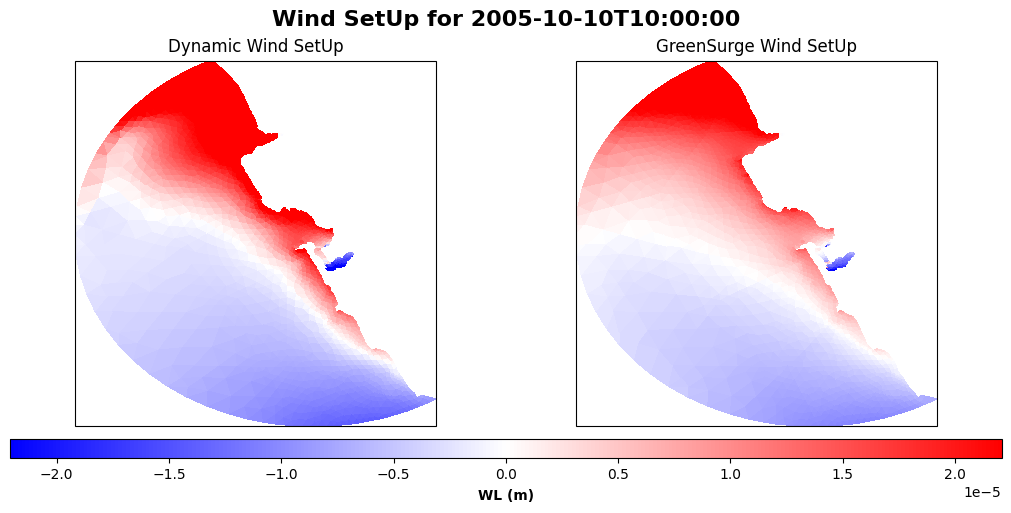

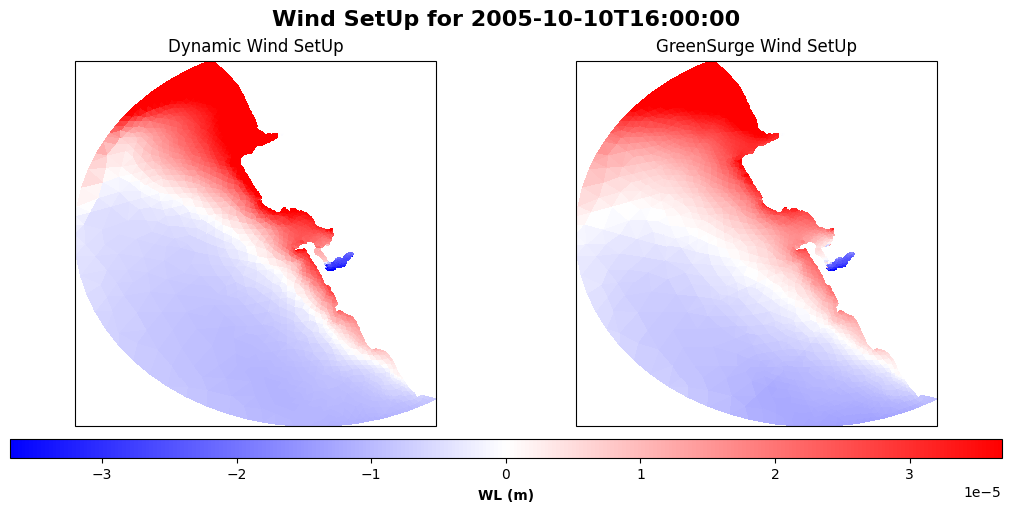

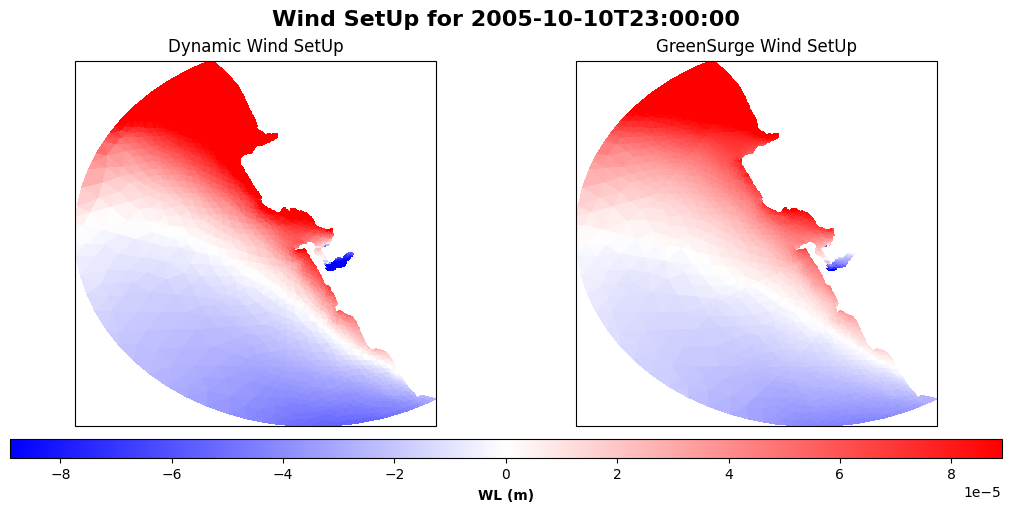

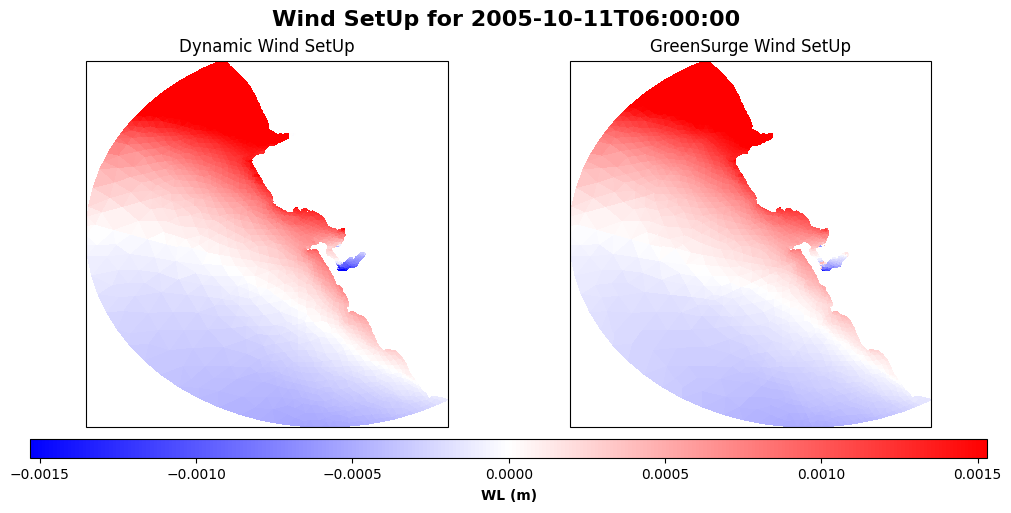

In [ ]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup

for i in instant:
    plot_GS_vs_dynamic_windsetup(
        ds_WL_GS_WindSetUp = ds_wind_setup,
        ds_WL_dynamic_WindSetUp = ds_WL_dynamic_WindSetUp,
        ds_gfd_metadata = ds_GFD_info_update,
        time = ds_WL_dynamic_WindSetUp.time[i].values,
        figsize = figsize,
    )